# Notebook 2: Preprocessing & Feature Engineering
## One-Hot Encoding, Splitting, and DataLoader Creation

**Inputs:** Cleaned pol gene sequences from Notebook 01

**Outputs:** Train/Val/Test DataLoaders ready for model training

---

### Why this notebook?
Deep learning models cannot process raw text strings like 'ATGC...'. We need to convert each nucleotide sequence into a **numerical tensor**. We use **one-hot encoding**, where each nucleotide *or gap character* is represented as a **4-dimensional vector** (4 for nucleotides):
- A = [1, 0, 0, 0, 0]
- C = [0, 1, 0, 0, 0]
- G = [0, 0, 1, 0, 0]
- T = [0, 0, 0, 1, 0]
- "-" = [0, 0, 0, 0, 1] (for gap characters)

This preserves the **positional information** of each base/gap in the genome which is critical for CNNs to detect local sequence motifs that distinguish subtypes.

### Why One-hot encoding transformation?
One-hot encoding is particularly suitable for HIV subtype classification because:

*   **Preserves Categorical Nature:** Nucleotides (A, C, G, T) and gaps (-) are distinct categories, and one-hot encoding treats them as such without implying any ordinal relationship (e.g., A is not 'greater' than C).
*   **Highlights Sequence Motifs:** By converting each base/gap into a unique binary vector, it allows convolutional neural networks (CNNs) to easily identify and learn distinct sequence patterns (motifs) that are characteristic of different HIV subtypes. Each position becomes a small, independent feature vector.
*   **Prevents Misinterpretation of Magnitude:** Unlike simple label encoding (e.g., A=0, C=1, G=2, T=3), one-hot encoding avoids creating artificial numerical relationships between nucleotides that could mislead a neural network into inferring incorrect magnitudes or distances between bases.
*   **Sufficient Feature Representation:** For genomic data, where the exact position and type of nucleotide are crucial, one-hot encoding provides a direct and unambiguous representation that is rich enough for deep learning models to extract meaningful features.

## Environment Setup & Library Imports

In [1]:
!pip -q install biopython

import os, sys
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
import pickle


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.2 MB/s eta 0:00:00


## Project Infrastructure & Device Setup

In [2]:
from google.colab import drive # Import drive from google.colab to mount Google Drive
drive.mount('/content/drive') # Mount Google Drive to access files

projectdir = '/content/drive/MyDrive/Deep Learning/hiv-subtype-classifier_final' # Base project directory path
rawdata = os.path.join(projectdir, 'data', 'raw') # path for raw data
processed_data = os.path.join(projectdir, 'data', 'processed') # path for processed data
reports = os.path.join(projectdir, 'reports', 'figures') # path for figures and reports

# Add src to path
sys.path.insert(0, os.path.join(projectdir, 'src'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Mounted at /content/drive
Device: cuda
GPU: Tesla T4


## Load cleaned data from Notebook 01

In [3]:
df = pd.read_pickle(os.path.join(processed_data, 'sequences_cleaned.pkl'))
print(f'Loaded {len(df)} pol gene sequences')
print(df['subtype_class'].value_counts())

Loaded 5564 pol gene sequences
subtype_class
B    2908
C    2303
A     278
D      75
Name: count, dtype: int64


## Step 1: Sequence Gap Stripping (Unaligned Conversion)
LANL sequences are pre-aligned using '-' gap characters. Traditional machine learning tools require these alignments. However, to build an advanced, fast, and alignment-free diagnostic tool, we want our CNN to operate on **raw, unaligned nucleotides**.

Here, we strip the gap characters permanently from the master dataset. This gives us perfectly gene-trimmed sequences, but in an unaligned format. Sequences will now naturally vary in length!

Original sequence lengths (with gaps):
count    5564.0
mean     4259.0
std         0.0
min      4259.0
25%      4259.0
50%      4259.0
75%      4259.0
max      4259.0
Name: sequence, dtype: float64

New sequence lengths (after stripping gaps):
count    5564.000000
mean     3010.840762
std        11.196470
min      2917.000000
25%      3000.000000
50%      3012.000000
75%      3015.000000
max      3099.000000
Name: sequence, dtype: float64


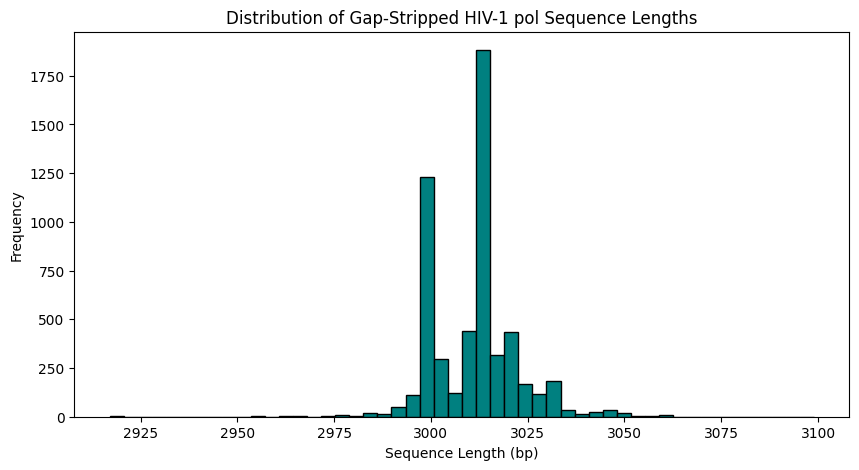

In [4]:
MAX_LENGTH = None
import matplotlib.pyplot as plt

print("Original sequence lengths (with gaps):")
print(df['sequence'].apply(len).describe())

# Strip the '-' characters from all sequences permanently
df['sequence'] = df['sequence'].str.replace('-', '')

print("\nNew sequence lengths (after stripping gaps):")
print(df['sequence'].apply(len).describe())

# Plot the new length distribution
plt.figure(figsize=(10, 5))
plt.hist(df['sequence'].apply(len), bins=50, color='teal', edgecolor='black')
plt.title('Distribution of Gap-Stripped HIV-1 pol Sequence Lengths')
plt.xlabel('Sequence Length (bp)')
plt.ylabel('Frequency')
plt.show()


## Step 2: Create Label Mapping
PyTorch's `CrossEntropyLoss` requires integer labels (0, 1, 2, 3), not strings ('A', 'B', 'C', 'D'). We create a consistent mapping and store it for use in evaluation and deployment.

In [5]:
# Create integer labels
classes = sorted(df['subtype_class'].unique())
label_to_idx = {label: idx for idx, label in enumerate(classes)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}
num_classes = len(classes)

print(f'Number of classes: {num_classes}')
print(f'Label mapping: {label_to_idx}')

df['label'] = df['subtype_class'].map(label_to_idx)

Number of classes: 4
Label mapping: {'A': 0, 'B': 1, 'C': 2, 'D': 3}


## Step 3: Train/Validation/Test Split
70% train / 15% validation / 15% test — **stratified** by subtype.

With imbalanced classes (e.g., subtype B has many more sequences than D), a random split could leave some classes underrepresented in the test set. Stratification ensures each split has the same class proportions as the full dataset.

### Why three splits?

*   **Training Set:** For train the model, allowing it to learn patterns and relationships in the data.
*   **Validation Set:** To be used during model development for hyperparameter tuning and model selection. It provides an unbiased evaluation of a model fit on the training data while tuning model hyperparameters. This helps prevent overfitting to the test set.
*   **Test Set:** Provides a final, unbiased evaluation of the model's performance on unseen data. It's crucial to only use the test set once, after all model development and hyperparameter tuning are complete.

In [6]:
X = df['sequence'].tolist()
y = df['label'].tolist()

# First: train+val vs test (85% vs 15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Second: train vs val (70% vs 15% of total = ~17.6% of trainval)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.176, random_state=42, stratify=y_trainval
)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

print(f'\nTrain class distribution:')
for cls, name in idx_to_label.items():
    count = y_train.count(cls)
    print(f'  {name}: {count} ({100*count/len(y_train):.1f}%)')

print(f'\nValidation class distribution:')
for cls, name in idx_to_label.items():
    count = y_val.count(cls)
    print(f'  {name}: {count} ({100*count/len(y_val):.1f}%)')

print(f'\nTest class distribution:')
for cls, name in idx_to_label.items():
    count = y_test.count(cls)
    print(f'  {name}: {count} ({100*count/len(y_test):.1f}%)')

Train: 3896 | Val: 833 | Test: 835

Train class distribution:
  A: 194 (5.0%)
  B: 2037 (52.3%)
  C: 1612 (41.4%)
  D: 53 (1.4%)

Validation class distribution:
  A: 42 (5.0%)
  B: 435 (52.2%)
  C: 345 (41.4%)
  D: 11 (1.3%)

Test class distribution:
  A: 42 (5.0%)
  B: 436 (52.2%)
  C: 346 (41.4%)
  D: 11 (1.3%)


### Verify Stratified Split Distribution

To ensure our stratify parameter worked correctly, we compile the class counts for each split into a summary table. This proves that the severely imbalanced classes (like Subtype D) are proportionately represented in the Train, Validation, and Test sets, rather than accidentally being clustered entirely into one group.

In [7]:
import pandas as pd
from collections import Counter

# Get class counts for each split
train_counts = Counter(y_train)
val_counts = Counter(y_val)
test_counts = Counter(y_test)

# Prepare data for DataFrame
data = {
    'Split': ['Train', 'Validation', 'Test']
}

for cls_idx in sorted(idx_to_label.keys()):
    subtype_name = idx_to_label[cls_idx]
    data[subtype_name] = [
        f'{train_counts.get(cls_idx, 0)} ({100*train_counts.get(cls_idx, 0)/len(y_train):.1f}%)',
        f'{val_counts.get(cls_idx, 0)} ({100*val_counts.get(cls_idx, 0)/len(y_val):.1f}%)',
        f'{test_counts.get(cls_idx, 0)} ({100*test_counts.get(cls_idx, 0)/len(y_test):.1f}%)'
    ]

# Create DataFrame
distribution_df = pd.DataFrame(data)

display(distribution_df)

,Split,A,B,C,D
0,Train,194 (5.0%),2037 (52.3%),1612 (41.4%),53 (1.4%)
1,Validation,42 (5.0%),435 (52.2%),345 (41.4%),11 (1.3%)
2,Test,42 (5.0%),436 (52.2%),346 (41.4%),11 (1.3%)


## Step 4: Compute Class Weights
To prevent overfitting to the majority classes (B and C), we compute balanced class weights and save them to be used by the Focal Loss function in our deep learning models.

In [8]:
# ===== Compute Class Weights =====
from sklearn.utils.class_weight import compute_class_weight

# Compute balanced class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("Class weights for [A, B, C, D]:")
print(class_weights)

# Save to processed data folder
weights_path = os.path.join(processed_data, 'class_weights.pt')
torch.save(class_weights_tensor, weights_path)


Class weights for [A, B, C, D]:
[ 5.02061856  0.47815415  0.60421836 18.37735849]


## Step 5: Sequence Encoding & Dataset Creation

One-hot encoding represents each nucleotide position as a 4-dimensional binary vector. The resulting tensor has shape `(4, MAX_LENGTH)` — this is equivalent to a 4-channel "image" that 1D convolutional filters can slide across to detect motifs.

We also create a label-encoded version for the BiLSTM model, which uses an embedding layer instead.

In [9]:
all_sequences = ''.join(df['sequence'].tolist())
unique_chars = sorted(list(set(all_sequences.upper())))

print(f"All unique characters found in sequences: {unique_chars}")

from collections import Counter

char_counts = Counter(all_sequences.upper())

print("\nCharacter counts:")
for char, count in sorted(char_counts.items()):
    print(f"  '{char}': {count}")

All unique characters found in sequences: ['A', 'B', 'C', 'D', 'G', 'H', 'K', 'M', 'N', 'R', 'S', 'T', 'V', 'W', 'Y']

Character counts:
  'A': 6520443
  'B': 14
  'C': 2792067
  'D': 35
  'G': 3811310
  'H': 42
  'K': 836
  'M': 1646
  'N': 2747
  'R': 12015
  'S': 368
  'T': 3602522
  'V': 24
  'W': 1285
  'Y': 6964


### Handling Ambiguous Bases

Output from the above code chunk shows that our sequences contain ambiguous bases (e.g., B, D, N, R), representing uncertain nucleotides. Our one-hot encoding strategy (`NUC_TO_IDX = {'A': 0, 'C': 1, 'G': 2, 'T': 3}`) treats these by representing them as an **all-zero vector** in the encoded sequence.

#### Why this approach?

This method effectively treats ambiguous bases as 'unknown' or 'not applicable' rather than forcing an arbitrary assignment. It's a robust and common practice in bioinformatics to avoid introducing false signals, especially given their low frequency. This helps the model focus on clearer patterns from standard nucleotides, enhancing overall model robustness.

In [10]:
NUC_TO_IDX = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

class HIVSequenceDataset(Dataset):
    """PyTorch Dataset with one-hot encoding for HIV pol sequences."""

    def __init__(self, sequences, labels, max_length=None, encoding='onehot'):
        self.sequences = sequences
        self.labels = labels
        self.max_length = max_length
        self.encoding = encoding

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        if self.max_length is not None:
            seq = seq[:self.max_length]

        label = torch.tensor(self.labels[idx], dtype=torch.long)

        if self.encoding == 'onehot':
            encoded = np.zeros((4, len(seq)), dtype=np.float32)
            for i, nuc in enumerate(seq):
                nuc_idx = NUC_TO_IDX.get(nuc.upper())
                if nuc_idx is not None:
                    encoded[nuc_idx, i] = 1.0
            return torch.tensor(encoded, dtype=torch.float32), label
        else:  # label encoding for BiLSTM
            encoded = np.full(len(seq), 4, dtype=np.int64)
            for i, nuc in enumerate(seq):
                encoded[i] = NUC_TO_IDX.get(nuc.upper(), 4)
            return torch.tensor(encoded), label

def pad_collate_fn(batch):
    sequences, labels = zip(*batch)
    labels = torch.stack(labels)

    if sequences[0].dim() == 2: # One-hot (4, L)
        max_len = max([s.size(1) for s in sequences])
        padded_seqs = torch.zeros(len(sequences), 4, max_len)
        for i, s in enumerate(sequences):
            end = s.size(1)
            padded_seqs[i, :, :end] = s
    else: # Label encoding (L,)
        max_len = max([s.size(0) for s in sequences])
        padded_seqs = torch.full((len(sequences), max_len), 4, dtype=torch.long)
        for i, s in enumerate(sequences):
            end = s.size(0)
            padded_seqs[i, :end] = s

    return padded_seqs, labels

# Create datasets
train_dataset = HIVSequenceDataset(X_train, y_train, MAX_LENGTH)
val_dataset = HIVSequenceDataset(X_val, y_val, MAX_LENGTH)
test_dataset = HIVSequenceDataset(X_test, y_test, MAX_LENGTH)

print(f'Dataset sizes: train={len(train_dataset)}, '
      f'val={len(val_dataset)}, test={len(test_dataset)}')

# Verify shapes
sample_x, sample_y = train_dataset[0]
print(f'Input shape: {sample_x.shape}')
print(f'Label: {sample_y.item()} = {idx_to_label[sample_y.item()]}')


Dataset sizes: train=3896, val=833, test=835
Input shape: torch.Size([4, 3000])
Label: 2 = C


### Verify One-Hot Encoding

Let's manually inspect a sample to confirm the one-hot encoding is working as expected. We'll take the first sequence from the `train_dataset` and visually compare its raw sequence with the one-hot encoded tensor.

In [11]:
# Take a sample from the training dataset
sample_seq_encoded, sample_label = train_dataset[0]
raw_sample_seq = X_train[0]

print(f"Raw Sample Sequence (first 50 chars): {raw_sample_seq[:50]}")
print(f"Raw Sample Sequence (last 50 chars): {raw_sample_seq[-50:]}")
print(f"\nOne-Hot Encoded Sample Shape: {sample_seq_encoded.shape}")

# Display the one-hot encoding for the first 10 characters
print("\nOne-Hot Encoding for first 10 characters (rows are A, C, G, T, -):")
print(sample_seq_encoded[:, :10])

# Display the one-hot encoding for the last 10 characters
print("\nOne-Hot Encoding for last 10 characters (rows are A, C, G, T, -):")
print(sample_seq_encoded[:, -10:])

# Manually verify a few characters
print("\nManual verification of a few characters:")
print(f"NUC_TO_IDX: {NUC_TO_IDX}")

# Example 1: First character
first_char = raw_sample_seq[0]
first_char_idx = NUC_TO_IDX.get(first_char.upper(), None)
print(f"  First char '{first_char}' (index {first_char_idx}) in raw sequence. One-hot column: {sample_seq_encoded[:, 0].tolist()}")

# Example 2: Ambiguous base handling (find an 'N' or other ambiguous base if present)
ambiguous_char = None
ambiguous_char_idx = -1
for i, char in enumerate(raw_sample_seq):
    if char.upper() not in NUC_TO_IDX:
        ambiguous_char = char
        ambiguous_char_idx = i
        break

if ambiguous_char:
    print(f"  Ambiguous char '{ambiguous_char}' (index {ambiguous_char_idx}) in raw sequence. One-hot column: {sample_seq_encoded[:, ambiguous_char_idx].tolist()}")
else:
    print("  No ambiguous characters (not in A, C, G, T, -) found in the sample sequence.")


Raw Sample Sequence (first 50 chars): TTTTTTAGGGAAAATTTGGCCTTCCCACAAGGGGAGGCCAGGGAATTTCC
Raw Sample Sequence (last 50 chars): AACAGATGGCAGGTGCTGATTGTGTGGCAGGTAGACAGGATGAGGATCAG

One-Hot Encoded Sample Shape: torch.Size([4, 3000])

One-Hot Encoding for first 10 characters (rows are A, C, G, T, -):
tensor([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 0., 0., 0., 0.]])

One-Hot Encoding for last 10 characters (rows are A, C, G, T, -):
tensor([[0., 0., 1., 0., 0., 1., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 1., 0., 1., 1., 0., 0., 0., 0., 1.],
        [1., 0., 0., 0., 0., 0., 1., 0., 0., 0.]])

Manual verification of a few characters:
NUC_TO_IDX: {'A': 0, 'C': 1, 'G': 2, 'T': 3}
  First char 'T' (index 3) in raw sequence. One-hot column: [0.0, 0.0, 0.0, 1.0]
  Ambiguous char 'R' (index 140) in raw sequence. One-hot column:

## Step 6: Create DataLoaders

`DataLoaders` are essential for efficiently feeding data to deep learning models. They provide:

*   **Batching:** Grouping samples into mini-batches for optimized training.
*   **Shuffling:** Randomizing data each epoch to improve generalization.
*   **Parallel Loading:** Using `num_workers` to load data concurrently, preventing CPU bottlenecks.
*   **GPU Transfer Optimization:** `pin_memory=True` for faster data transfer to the GPU.

**For this task, we used the following options;**

*   **`batch_size = 32`**: A common choice, balancing memory usage and training stability. Larger batches can train faster but require more memory and might generalize less effectively due to less frequent weight updates.
*   **`shuffle = True` (Train DataLoader)**: Randomizes the order of samples in each epoch. This is crucial for training to prevent the model from learning the order of the data and to improve generalization.
*   **`shuffle = False` (Validation and Test DataLoaders)**: For validation and testing, we want consistent, reproducible results, so shuffling is disabled.
*   **`num_workers = 2`**: Specifies the number of subprocesses to use for data loading. This offloads data preprocessing and loading from the main thread to separate CPU cores, preventing CPU bottlenecks and ensuring the GPU is kept busy.
*   **`pin_memory = True`**: This tells PyTorch to automatically move data to pinned (page-locked) memory. Pinned memory allows for faster and more efficient data transfer to the GPU, significantly speeding up training when using a CUDA-enabled GPU.

In [12]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True,
                          collate_fn=pad_collate_fn)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True,
                        collate_fn=pad_collate_fn)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True,
                         collate_fn=pad_collate_fn)

## Step 7: Save Preprocessed Data for Subsequent Notebooks

Training is computationally expensive. By saving the preprocessed splits and label mappings, we avoid re-running the preprocessing pipeline every time we restart a training notebook.

In [13]:
# Save everything needed for training notebooks
# Note: Ensure all previous cells (Step 1-6) have been executed successfully.

preprocessed_payload = {
    'X_train': X_train, 'y_train': y_train,
    'X_val': X_val, 'y_val': y_val,
    'X_test': X_test, 'y_test': y_test,
    'label_to_idx': label_to_idx,
    'idx_to_label': idx_to_label,
    'num_classes': num_classes,
    'max_length': MAX_LENGTH,
    }

# Define the destination path
save_path = os.path.join(processed_data, 'preprocessed_data.pkl')

# Create directory if it doesn't exist (safety check)
os.makedirs(os.path.dirname(save_path), exist_ok=True)

with open(save_path, 'wb') as f:
    pickle.dump(preprocessed_payload, f)

print(f'Successfully saved preprocessed data to {save_path}')
print(f'Samples per split: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}')
print(f'\n--- Ready for Notebook 03: Baseline Model ---')

Successfully saved preprocessed data to /content/drive/MyDrive/Deep Learning/hiv-subtype-classifier_final/data/processed/preprocessed_data.pkl
Samples per split: Train=3896, Val=833, Test=835

--- Ready for Notebook 03: Baseline Model ---
